## Aplicando filtros


In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# pylint: disable=reportAtributeAccessError

In [3]:
kernels = {
    "Media": np.ones((5, 5), np.float32) / 25,
    "Butterworth": np.array(
        [
            [1, 4, 6, 4, 1],
            [4, 16, 24, 16, 4],
            [6, 24, 36, 24, 6],
            [4, 16, 24, 16, 4],
            [1, 4, 6, 4, 1],
        ],
        dtype=np.float32,
    )
    / 256,
    "Gaussiano": cv2.getGaussianKernel(5, 1) @ cv2.getGaussianKernel(5, 1).T,
    "Laplaciano": np.array(
        [
            [0, 1, 0, 1, 0],
            [1, -4, 1, -4, 1],
            [0, 1, 8, 1, 0],
            [1, -4, 1, -4, 1],
            [0, 1, 0, 1, 0],
        ],
        dtype=np.float32,
    ),
    "Pasa Alta": np.array(
        [
            [-1, -1, -1, -1, -1],
            [-1, -1, -1, -1, -1],
            [-1, -1, 24, -1, -1],
            [-1, -1, -1, -1, -1],
            [-1, -1, -1, -1, -1],
        ],
        dtype=np.float32,
    ),
    "Pasa Baja": np.ones((5, 5), np.float32) / 25,
    "Pasa Media": np.array(
        [
            [0, -1, 0, -1, 0],
            [-1, 2, -1, 2, -1],
            [0, -1, 8, -1, 0],
            [-1, 2, -1, 2, -1],
            [0, -1, 0, -1, 0],
        ],
        dtype=np.float32,
    ),
}

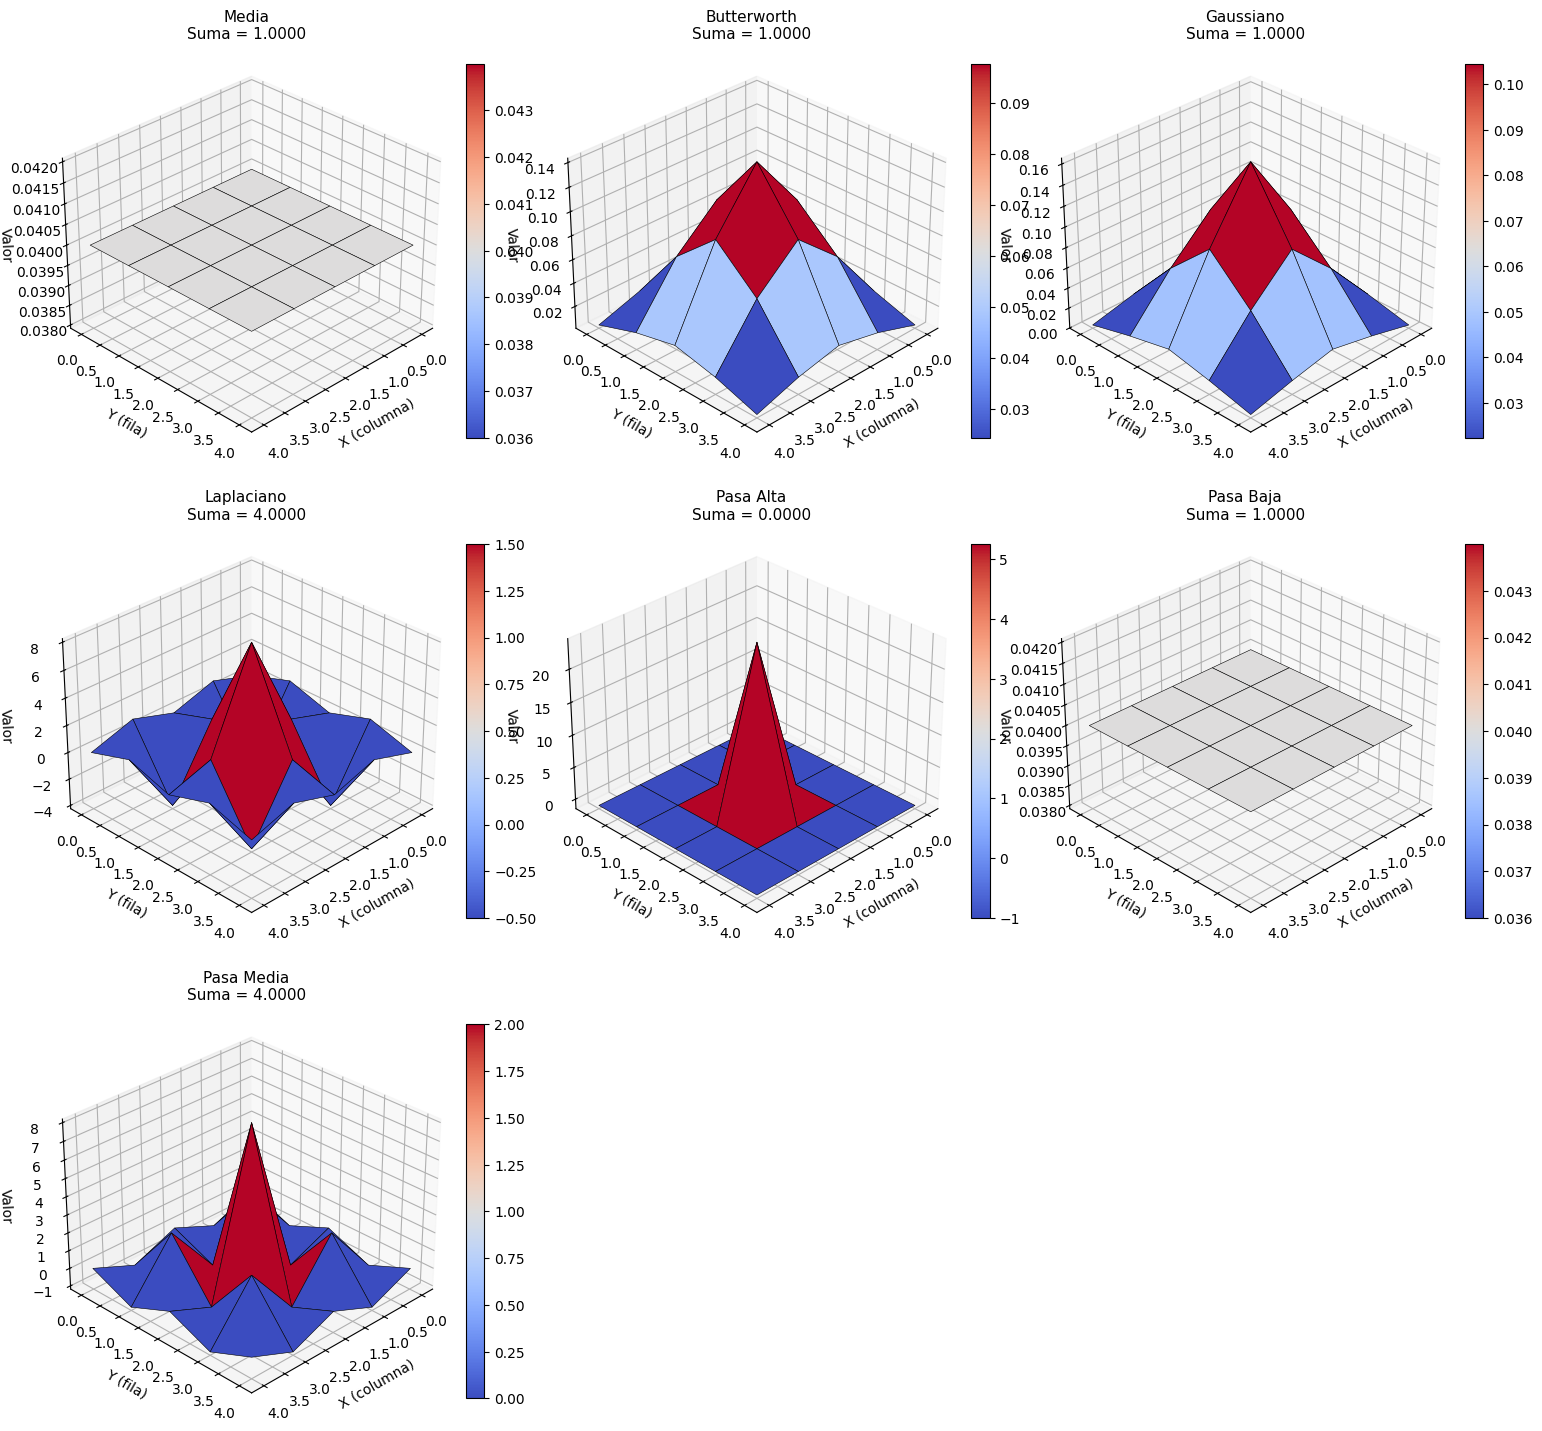

In [8]:
def plot_kernels_3d(kernels_dict, cmap="coolwarm", elev=30, azim=45, cols=3):
    n = len(kernels_dict)
    rows = int(np.ceil(n / cols))
    fig = plt.figure(figsize=(5 * cols, 4.8 * rows), constrained_layout=True)

    for idx, (name, kernel) in enumerate(kernels_dict.items(), start=1):
        ax = fig.add_subplot(rows, cols, idx, projection="3d")
        k = np.array(kernel, dtype=np.float32)

        # X e Y representan la posicion (fila, columna) de cada valor del kernel.
        x = np.arange(k.shape[1])
        y = np.arange(k.shape[0])
        X, Y = np.meshgrid(x, y)

        surf = ax.plot_surface(
            X, Y, k, cmap=cmap, linewidth=0.4, edgecolor="k", antialiased=True
        )

        ax.set_title(f"{name}\nSuma = {k.sum():.4f}", fontsize=11)
        ax.set_xlabel("X (columna)")
        ax.set_ylabel("Y (fila)")
        ax.set_zlabel("Valor")
        ax.view_init(elev=elev, azim=azim)
        fig.colorbar(surf, ax=ax, fraction=0.046, pad=0.04)

    plt.show()


plot_kernels_3d(kernels, cols=3)

In [13]:
def plot_img(img, title="Imagen", cmap=None):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

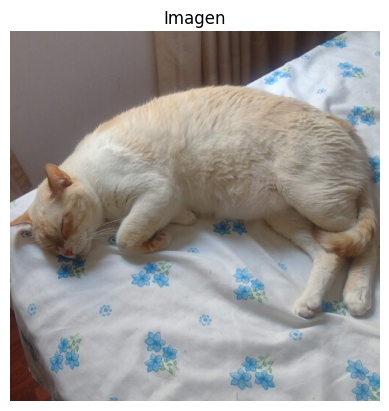

In [20]:
img = cv2.imread("liam3.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plot_img(img)

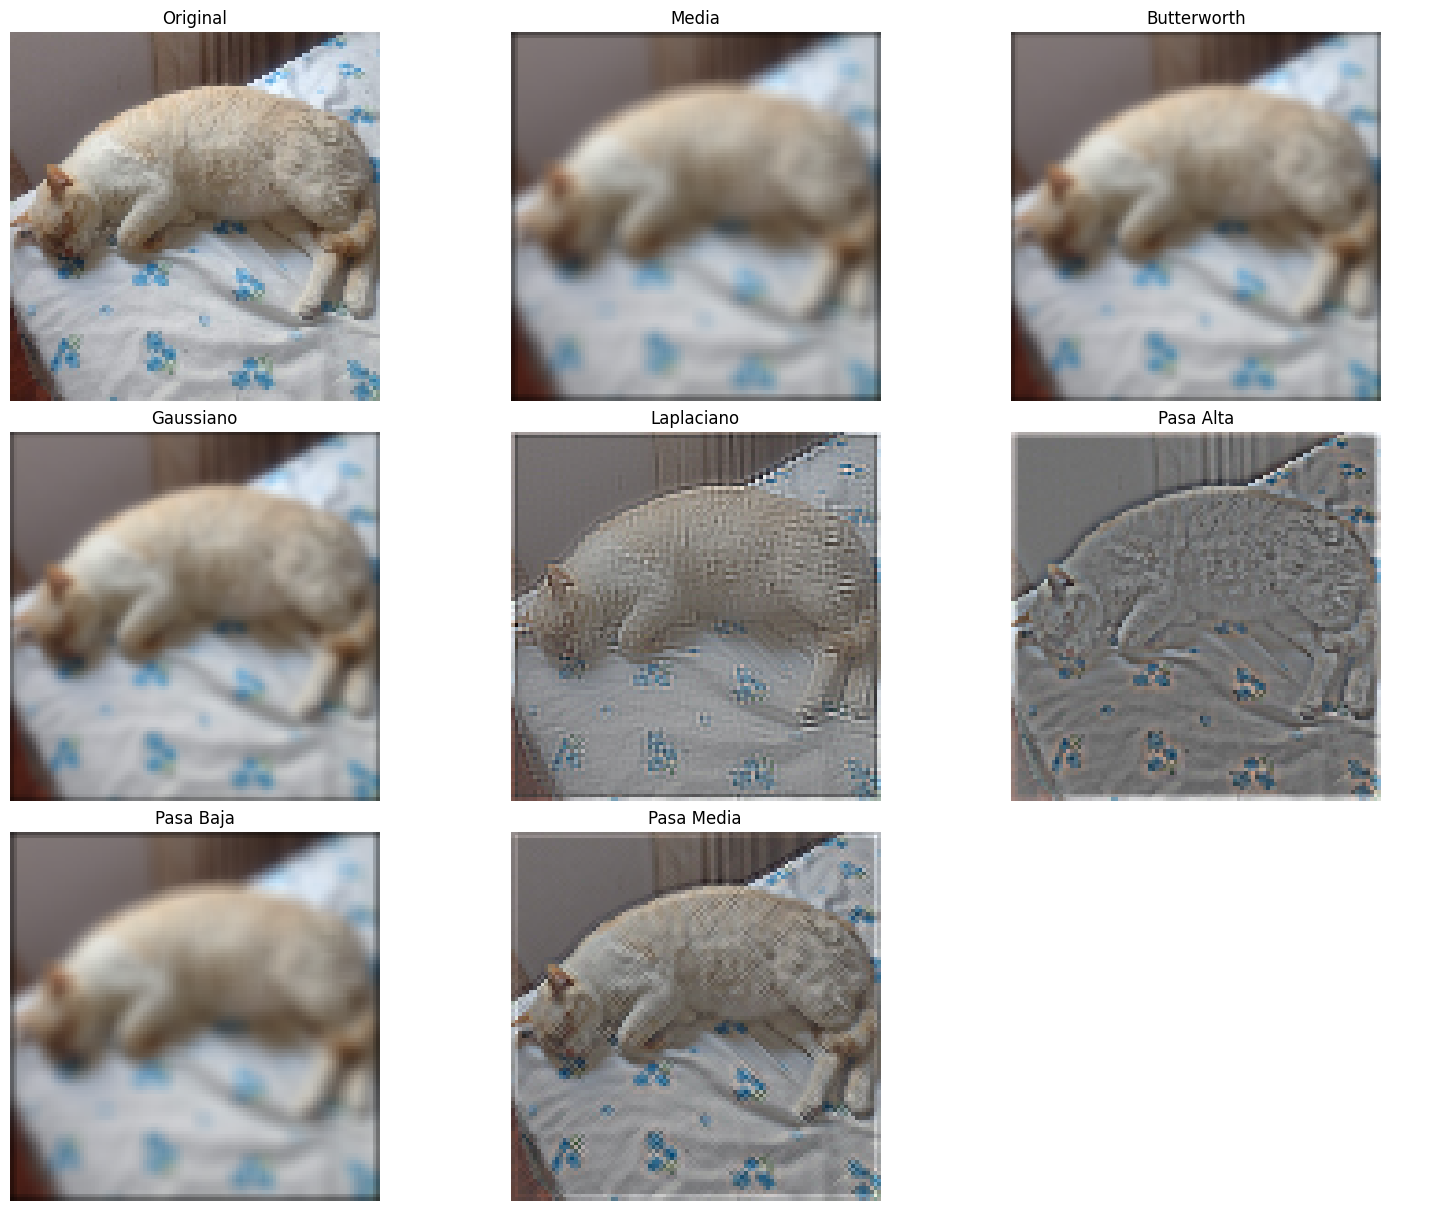

In [21]:
def convolve_manual(img, kernel):
    """
    Aplica convolucion 2D manualmente con triple for (fila, columna, canal).
    Usa padding de ceros para conservar el tamano original.
    """
    k = np.array(kernel, dtype=np.float32)
    kh, kw = k.shape
    pad_h, pad_w = kh // 2, kw // 2
    h, w, c = img.shape

    padded = np.pad(
        img.astype(np.float32),
        ((pad_h, pad_h), (pad_w, pad_w), (0, 0)),
        mode="constant",
    )
    output = np.zeros_like(img, dtype=np.float32)

    for i in range(h):  # for 1: recorre filas
        for j in range(w):  # for 2: recorre columnas
            for ch in range(c):  # for 3: recorre canales (R, G, B)
                region = padded[i : i + kh, j : j + kw, ch]
                output[i, j, ch] = np.sum(region * k)

    return output


def to_displayable(image):
    img_min, img_max = float(image.min()), float(image.max())
    if img_min < 0 or img_max > 255:
        vis = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    else:
        vis = np.clip(image, 0, 255)
    return vis.astype(np.uint8)


# Se reduce la imagen para que el triple for sea viable en tiempo.
small = cv2.resize(img, (100, 100))

cols = 3
total = len(kernels) + 1
rows = int(np.ceil(total / cols))
fig, axes = plt.subplots(
    rows, cols, figsize=(5 * cols, 4 * rows), constrained_layout=True
)
axes = np.array(axes).reshape(-1)

axes[0].imshow(small)
axes[0].set_title("Original")
axes[0].axis("off")

for idx, (name, kernel) in enumerate(kernels.items(), start=1):
    result = convolve_manual(small, kernel)
    axes[idx].imshow(to_displayable(result))
    axes[idx].set_title(name)
    axes[idx].axis("off")

for j in range(total, len(axes)):
    axes[j].axis("off")

plt.show()